<a href="https://colab.research.google.com/github/sultanjacob/Applied-Machine-Learning/blob/main/03_clustering/02_KMeans_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Unsupervised Learning (K-Means Clustering)

In this notebook, we take the clean master dataset generated in Phase 1 and apply K-Means clustering to discover hidden customer personas.

### Step 1: Loading & Scaling
K-Means groups data points by calculating the mathematical distance (Euclidean distance) between them. If we do not scale our features, variables with massive numbers (like `total_spend` in thousands of dollars) will completely overpower variables with small numbers (like `kids_encoded` which ranges from 0 to 3).

We use `StandardScaler` to force every column to have a mean of 0 and a standard deviation of 1, leveling the playing field.

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the uploaded file directly from session storage
df = pd.read_csv('master_customer_segments.csv')

# Drop household_id and non-numerical columns for scaling
household_ids = df['household_id']
numerical_features = df.select_dtypes(include=['int64', 'float64']).drop(columns=['household_id'], errors='ignore')

# Scale numerical columns so K-Means distance calculations are fair
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numerical_features)

print(f"Success! Loaded {scaled_features.shape[0]} rows and {scaled_features.shape[1]} features ready for clustering.")

Success! Loaded 801 rows and 8 features ready for clustering.


### Step 2: Finding the Optimal "K" (How many clusters?)

In unsupervised learning, we don't know the "right" answer in advance. We have to figure out how many distinct customer personas (K) naturally exist in our data. To do this mathematically, we will test every K from 2 to 10 and evaluate the results using two standard industry metrics:

1. **The Elbow Method (Inertia):** This calculates the Within-Cluster Sum of Squares (WCSS). It measures how tightly grouped the clusters are. We plot the results and look for the "elbow" or hinge in the line; the point where adding more clusters stops significantly improving the tightness.

2. **The Silhouette Score:** This measures how similar a customer is to their own cluster compared to other clusters. The score ranges from -1 to 1. A higher score means the clusters are highly distinct and well-separated. We look for the absolute peak on this chart.

Calculating cluster metrics. This may take a few seconds...

K=2 | Inertia (Tightness): 5,083 | Silhouette Score (Separation): 0.2725
K=3 | Inertia (Tightness): 4,516 | Silhouette Score (Separation): 0.2009
K=4 | Inertia (Tightness): 4,081 | Silhouette Score (Separation): 0.1713
K=5 | Inertia (Tightness): 3,717 | Silhouette Score (Separation): 0.1547
K=6 | Inertia (Tightness): 3,412 | Silhouette Score (Separation): 0.1565
K=7 | Inertia (Tightness): 3,191 | Silhouette Score (Separation): 0.1589
K=8 | Inertia (Tightness): 3,024 | Silhouette Score (Separation): 0.1559
K=9 | Inertia (Tightness): 2,872 | Silhouette Score (Separation): 0.1650
K=10 | Inertia (Tightness): 2,728 | Silhouette Score (Separation): 0.1708


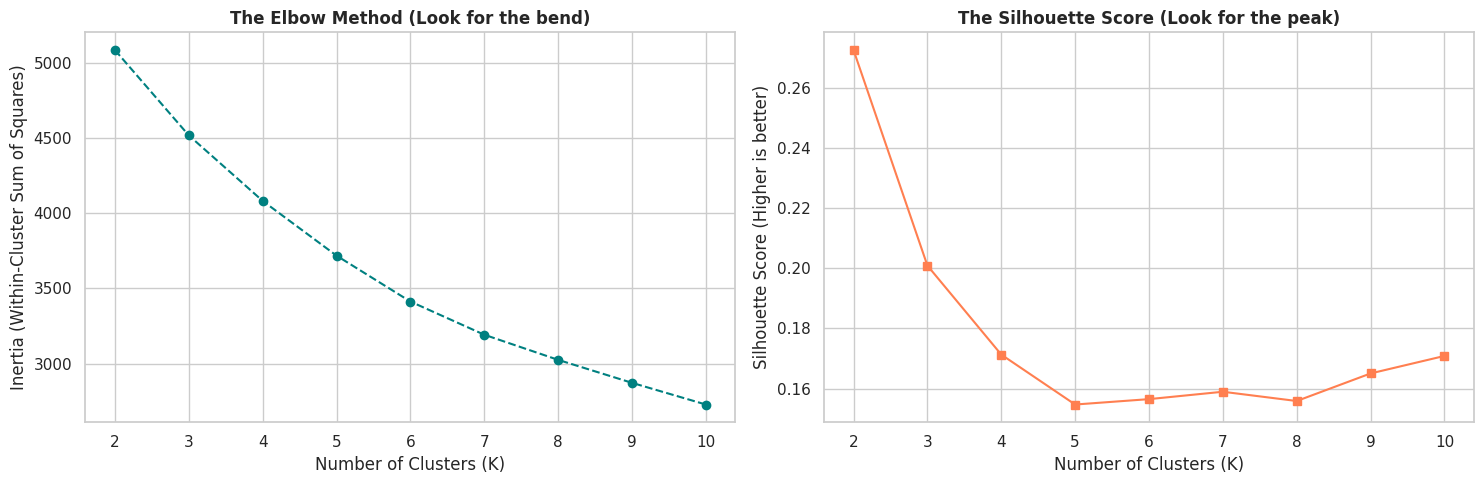

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean aesthetic for our graphs
sns.set_theme(style="whitegrid")

# Create empty lists to store the scores for each K
inertia_values = []
silhouette_scores = []

# We will test grouping the customers into anywhere from 2 to 10 segments
K_range = range(2, 11)

print("Calculating cluster metrics. This may take a few seconds...\n")

for k in K_range:
    # Initialize the algorithm (n_init=10 ensures it tries 10 different random starting points)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)

    # 1. Store the Inertia (for the Elbow Method)
    inertia_values.append(kmeans.inertia_)

    # 2. Store the Silhouette Score
    sil_score = silhouette_score(scaled_features, kmeans.labels_)
    silhouette_scores.append(sil_score)

    print(f"K={k} | Inertia (Tightness): {kmeans.inertia_:,.0f} | Silhouette Score (Separation): {sil_score:.4f}")

# --- VISUALIZING BOTH METHODS ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: The Elbow Method
axes[0].plot(K_range, inertia_values, marker='o', linestyle='--', color='teal')
axes[0].set_title('The Elbow Method (Look for the bend)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')

# Plot 2: The Silhouette Score
axes[1].plot(K_range, silhouette_scores, marker='s', linestyle='-', color='coral')
axes[1].set_title('The Silhouette Score (Look for the peak)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (Higher is better)')

plt.tight_layout()
plt.show()